<center> <h1> Teen Mental-Health Prediction Classification Project </h1> </center>

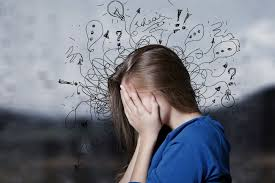

In [99]:
from IPython.display import Image,display
display(Image(filename="teen.jpg"))

In [100]:
#Import required libraries:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import time

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN
from sklearn.model_selection import GridSearchCV



#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")


#Import the dataset:
df = pd.read_csv("dataset.csv")

In [101]:
#Preview the data:
df.sample(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1187,18,male,2.0,Instagram,8.9,0.8,2.96,0.5,medium,6,2,2,0
847,15,female,4.2,TikTok,6.8,1.4,2.01,1.0,low,6,6,4,0
681,19,male,6.8,Instagram,8.4,2.1,3.15,2.0,medium,4,10,1,0
785,19,female,5.0,Instagram,6.3,2.9,2.04,0.5,medium,5,2,2,0
786,19,female,4.2,Instagram,7.1,2.5,3.91,1.5,high,6,8,9,0


In [102]:
#Shape of the data:
df.shape

(1200, 13)

In [103]:
#Detailed info about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [104]:
#No. of null values in each attribute:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [105]:
#View a statistical summary of the dataset:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


<Axes: xlabel='platform_usage', ylabel='count'>

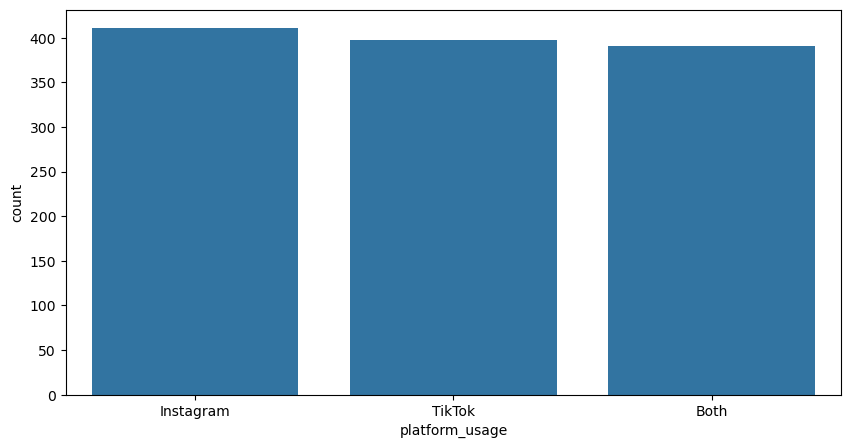

In [106]:
#Social Media Platforms:
plt.figure(figsize=(10,5))
sns.countplot(x="platform_usage",data=df)

In [107]:

X = df.drop(["depression_label", "stress_level"], axis=1)
y = df["depression_label"]

#Split the data into training and testing set:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [108]:
# Evidence for using SMOTE
print("Before SMOTE:")
print(y_train.value_counts())


# Fix the imbalance in the training data using SMOTENC
from imblearn.over_sampling import SMOTENC

# Categorical columns in X
cat_cols = ["gender", "platform_usage", "social_interaction_level"]

# Get their column positions
cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

# Apply SMOTENC
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=2)
X_trainsmote, y_trainsmote = smote_nc.fit_resample(X_train, y_train)


X_trainsmote_encoded = pd.get_dummies(X_trainsmote, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Make both datasets have same columns
X_trainsmote_encoded, X_test_encoded = X_trainsmote_encoded.align(
    X_test_encoded, join="left", axis=1, fill_value=0
)

print("After SMOTE:")
print(y_trainsmote.value_counts())

Before SMOTE:
depression_label
0    935
1     25
Name: count, dtype: int64
After SMOTE:
depression_label
0    935
1    935
Name: count, dtype: int64


In [109]:
# Decision Tree Classifier
dec_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dec_model.fit(X_trainsmote_encoded, y_trainsmote)

# Predictions
train_predictions = dec_model.predict(X_trainsmote_encoded)
test_predictions = dec_model.predict(X_test_encoded)

# Accuracy
accuracy_on_train = accuracy_score(y_trainsmote, train_predictions)
accuracy_on_test = accuracy_score(y_test, test_predictions)

print("Training Accuracy:", accuracy_on_train)
print("Testing Accuracy:", accuracy_on_test)
print("\nClassification Report:\n")
print(classification_report(y_test, test_predictions))

Training Accuracy: 0.990909090909091
Testing Accuracy: 0.95

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       234
           1       0.25      0.50      0.33         6

    accuracy                           0.95       240
   macro avg       0.62      0.73      0.65       240
weighted avg       0.97      0.95      0.96       240



In [110]:
results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_trainsmote_encoded, y_trainsmote)
    pred = model.predict(X_test_encoded)
    
    acc = accuracy_score(y_test, pred)
    
    results[name] = acc
    trained_models[name] = model

# Get best model
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])

Best Model: Random Forest
Best Accuracy: 0.9666666666666667


In [111]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(),
}

for name, model in models.items():
    model.fit(X_trainsmote_encoded, y_trainsmote)
    pred = model.predict(X_test_encoded)
    cr = classification_report(y_test, pred)
    print(f"{name}:\n {cr}")
    print("\n\n\n")

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.29      0.83      0.43         6

    accuracy                           0.95       240
   macro avg       0.64      0.89      0.70       240
weighted avg       0.98      0.95      0.96       240





KNN:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97       234
           1       0.26      0.83      0.40         6

    accuracy                           0.94       240
   macro avg       0.63      0.89      0.68       240
weighted avg       0.98      0.94      0.95       240





Naive Bayes:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.29      0.83      0.43         6

    accuracy                           0.95       240
   macro avg       0.64      0.89      0.70       240
weighted avg       0.98 

In [112]:
# Cross Validation
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":"accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

results = []

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_trainsmote_encoded,
        y_trainsmote,
        cv=kf,
        scoring=scoring
    )

    accuracy = np.mean(cv_results["test_accuracy"])
    precision = np.mean(cv_results["test_precision"])
    recall = np.mean(cv_results["test_recall"])
    f1_score = np.mean(cv_results["test_f1"])

    results.append({
        "Model Name": name,
        "Accuracy": round(accuracy, 2),
        "Precision": round(precision, 2),
        "Recall": round(recall, 2),
        "F1-Score": round(f1_score, 2),
    })

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print(results_df)

            Model Name  Accuracy  Precision  Recall  F1-Score
4        Random Forest      0.99       0.98    1.00      0.99
3        Decision Tree      0.98       0.96    0.99      0.98
2          Naive Bayes      0.97       0.95    0.99      0.97
1                  KNN      0.96       0.92    1.00      0.96
0  Logistic Regression      0.94       0.92    0.98      0.95


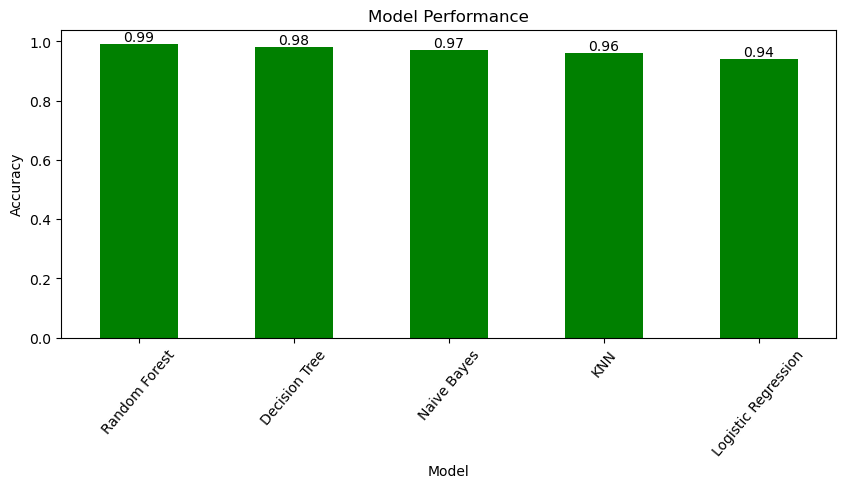

In [113]:

plt.figure(figsize=(10, 4))

ax = results_df.set_index("Model Name")["Accuracy"].plot(kind='bar',color="green")

plt.title("Model Performance")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=50)

# Add labels on each bar
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.01, str(v), ha='center')

plt.show()

In [114]:
best_model

RandomForestClassifier()

In [115]:
#Export the best performing model:
import joblib
joblib.dump(best_model,"teen_mental_health_prediction_model.pkl")

['teen_mental_health_prediction_model.pkl']

### Project made by:
- **Name** : Om Satyawan Pathak
- **Email** : omsatyawanpathakgit@gmail.com
- **Linkedin Profile**: www.linkedin.com/in/om-satyawan-pathak-029b02368